Akshat Keshri (iitp_aiml_2506515 )

---



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
BASE_PATH = "/content/drive/MyDrive/T2_Project_Akshat_Keshri"

In [ ]:
import joblib

lr_pipeline = joblib.load(f"{BASE_PATH}/Models/logistic_regression.pkl")
dt_model    = joblib.load(f"{BASE_PATH}/Models/decision_tree.pkl")
rf_model    = joblib.load(f"{BASE_PATH}/Models/random_forest_baseline.pkl")
rf_best     = joblib.load(f"{BASE_PATH}/Models/random_forest_tuned.pkl")
xgb_model   = joblib.load(f"{BASE_PATH}/Models/xgboost_baseline.pkl")
xgb_best    = joblib.load(f"{BASE_PATH}/Models/xgboost_tuned.pkl")

In [ ]:
import pandas as pd

test_df = pd.read_csv(f"{BASE_PATH}/Dataset/test_data.csv")

X_test = test_df.drop("Risk", axis=1)
y_test = test_df["Risk"]

In [ ]:
import pandas as pd

train_df = pd.read_csv(f"{BASE_PATH}/Dataset/train_data.csv")
test_df  = pd.read_csv(f"{BASE_PATH}/Dataset/test_data.csv")

X_train = train_df.drop("Risk", axis=1)
y_train = train_df["Risk"]

X_test = test_df.drop("Risk", axis=1)
y_test = test_df["Risk"]

In [ ]:
import joblib

rf_model  = joblib.load(f"{BASE_PATH}/Models/random_forest_tuned.pkl")
xgb_model = joblib.load(f"{BASE_PATH}/Models/xgboost_tuned.pkl")

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)
import pandas as pd

In [ ]:
def evaluate_model(model, X_test, y_test, model_name):
    # Predictions
    y_pred = model.predict(X_test)

    # Probabilities (needed for ROC-AUC)
    if hasattr(model, "predict_proba"):
        y_pred_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_pred_proba = None

    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else None
    }

    print(f"\n Classification Report — {model_name}")
    print(classification_report(y_test, y_pred))

    return metrics

In [ ]:
results = []

results.append(evaluate_model(lr_pipeline, X_test, y_test, "Logistic Regression"))
results.append(evaluate_model(dt_model, X_test, y_test, "Decision Tree"))
results.append(evaluate_model(rf_model, X_test, y_test, "Random Forest (Baseline)"))
results.append(evaluate_model(rf_best, X_test, y_test, "Random Forest (Tuned)"))
results.append(evaluate_model(xgb_model, X_test, y_test, "XGBoost (Baseline)"))
results.append(evaluate_model(xgb_best, X_test, y_test, "XGBoost (Tuned)"))


 Classification Report — Logistic Regression
              precision    recall  f1-score   support

           0       0.84      0.85      0.85       120
           1       0.77      0.76      0.77        80

    accuracy                           0.81       200
   macro avg       0.81      0.81      0.81       200
weighted avg       0.81      0.81      0.81       200


 Classification Report — Decision Tree
              precision    recall  f1-score   support

           0       0.82      0.86      0.84       120
           1       0.77      0.72      0.75        80

    accuracy                           0.81       200
   macro avg       0.80      0.79      0.79       200
weighted avg       0.80      0.81      0.80       200


 Classification Report — Random Forest (Baseline)
              precision    recall  f1-score   support

           0       0.86      0.84      0.85       120
           1       0.77      0.80      0.79        80

    accuracy                           0.82  

In [ ]:
metrics_df = pd.DataFrame(results)
metrics_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.815,0.772152,0.7625,0.767296,0.900729
1,Decision Tree,0.805,0.773333,0.7250,0.748387,0.791667
2,Random Forest (Baseline),0.825,0.771084,0.8000,0.785276,0.911406
3,Random Forest (Tuned),0.830,0.780488,0.8000,0.790123,0.913750
4,XGBoost (Baseline),0.830,0.773810,0.8125,0.792683,0.917083
5,XGBoost (Tuned),0.835,0.790123,0.8000,0.795031,0.926250


In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, roc_curve, precision_recall_curve

In [ ]:
BASE_PATH = "/content/drive/MyDrive/T2_Project_Akshat_Keshri"
PLOTS_DIR = f"{BASE_PATH}/Visualization/plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

In [ ]:
def save_plot(filename):
    plt.savefig(os.path.join(PLOTS_DIR, filename), dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

In [ ]:
metrics_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.815,0.772152,0.7625,0.767296,0.900729
1,Decision Tree,0.805,0.773333,0.7250,0.748387,0.791667
2,Random Forest (Baseline),0.825,0.771084,0.8000,0.785276,0.911406
3,Random Forest (Tuned),0.830,0.780488,0.8000,0.790123,0.913750
4,XGBoost (Baseline),0.830,0.773810,0.8125,0.792683,0.917083
5,XGBoost (Tuned),0.835,0.790123,0.8000,0.795031,0.926250


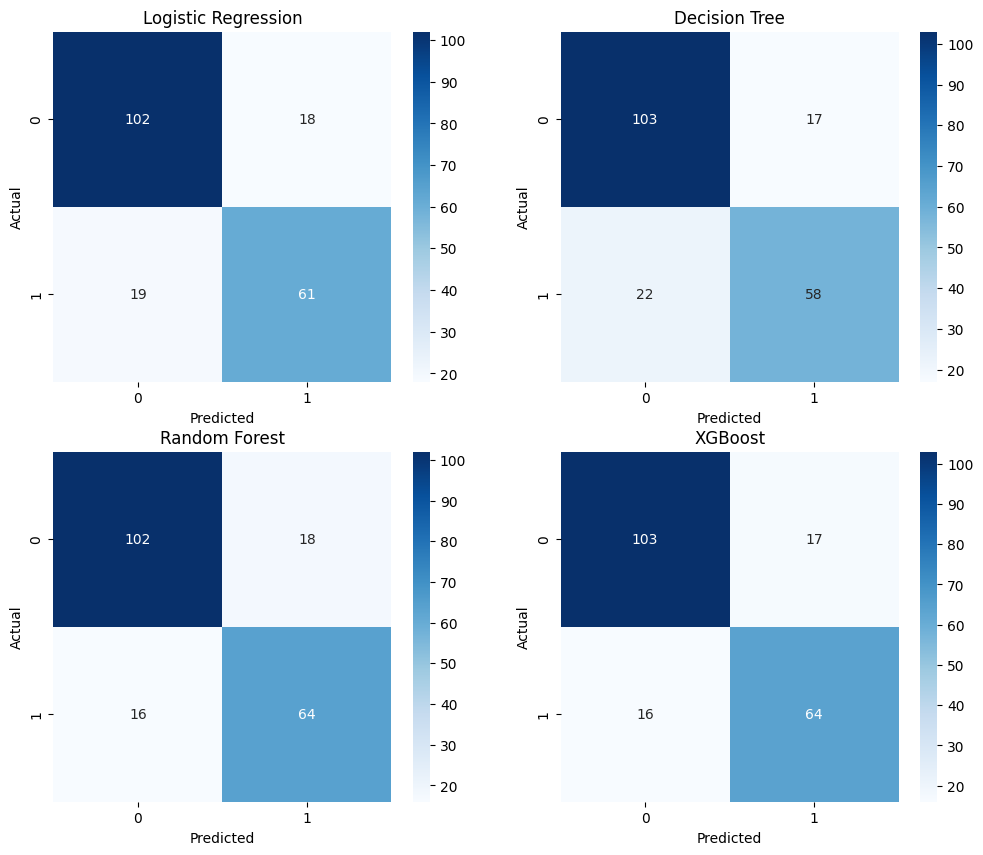

In [ ]:
models = {
    "Logistic Regression": lr_pipeline,
    "Decision Tree": dt_model,
    "Random Forest": rf_best,
    "XGBoost": xgb_best
}

plt.figure(figsize=(12,10))

for i, (name, model) in enumerate(models.items(), 1):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    plt.subplot(2, 2, i)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

save_plot("confusion_matrices.png")

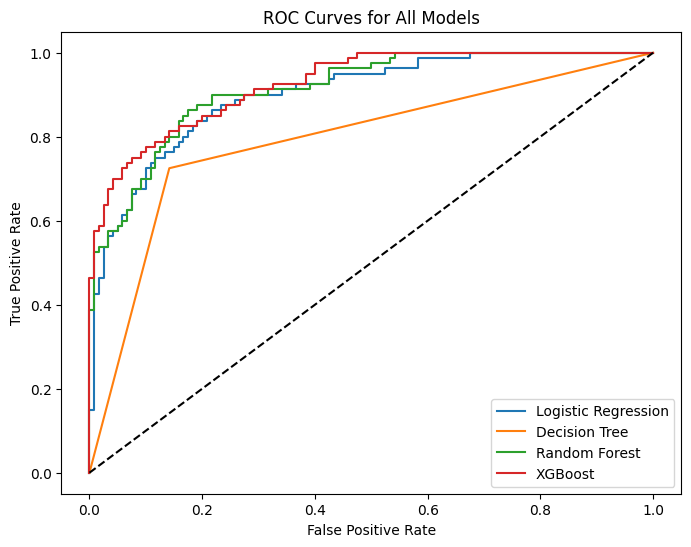

In [ ]:
plt.figure(figsize=(8,6))

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        plt.plot(fpr, tpr, label=name)

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for All Models")
plt.legend()

save_plot("roc_curves.png")

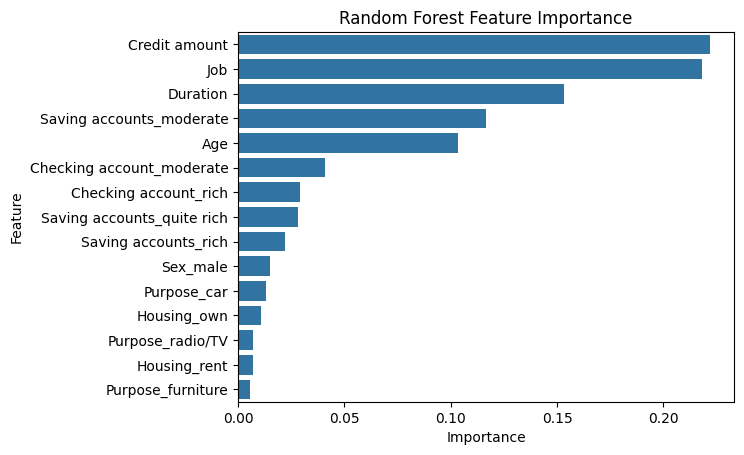

In [ ]:
rf_importance = rf_best.feature_importances_
features = X_test.columns

rf_imp_df = (
    pd.DataFrame({"Feature": features, "Importance": rf_importance})
    .sort_values(by="Importance", ascending=False)
    .head(15)
)

sns.barplot(data=rf_imp_df, x="Importance", y="Feature")
plt.title("Random Forest Feature Importance")

save_plot("rf_feature_importance.png")

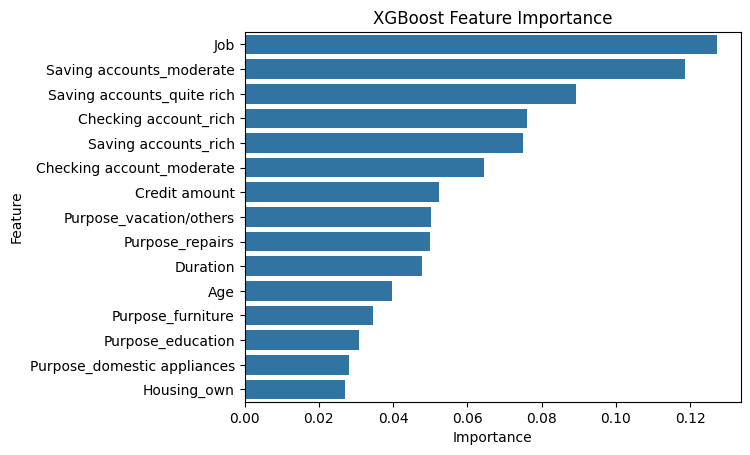

In [ ]:
xgb_importance = xgb_best.feature_importances_

xgb_imp_df = (
    pd.DataFrame({"Feature": features, "Importance": xgb_importance})
    .sort_values(by="Importance", ascending=False)
    .head(15)
)

sns.barplot(data=xgb_imp_df, x="Importance", y="Feature")
plt.title("XGBoost Feature Importance")

save_plot("feature_importance.png")


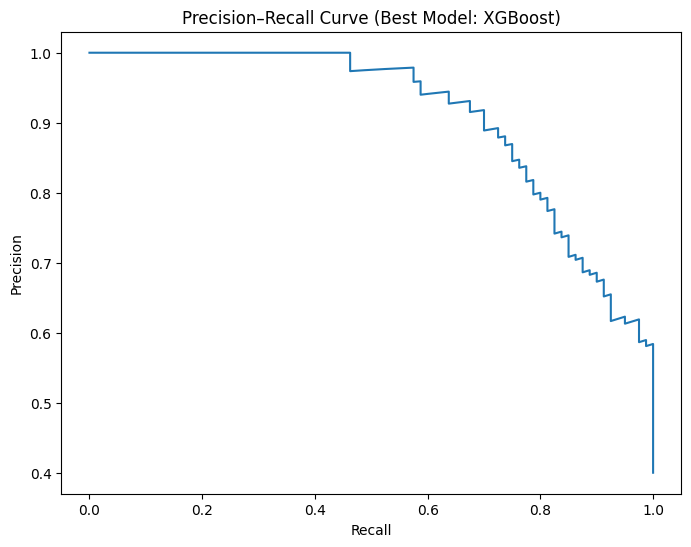

In [ ]:
y_proba_best = xgb_best.predict_proba(X_test)[:, 1]
precision, recall, _ = precision_recall_curve(y_test, y_proba_best)

plt.figure(figsize=(8,6))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (Best Model: XGBoost)")

save_plot("precision_recall_curve.png")